In [1]:
# ==============================================================================
# TASK 3: REAL-WORLD PRODUCT DATASET ANALYSIS (ZOMATO BANGALORE)
# Candidate: Pradeep Singh
# Domain: Food Delivery & Quick-Commerce Marketplace Analytics
# Dataset Source: Kaggle Open Data / Zomato Bangalore Restaurants Dataset
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Plot aesthetic standards
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

In [3]:
# ------------------------------------------------------------------------------
# 1. INGESTION & DATASET AUDITING
# ------------------------------------------------------------------------------
print("Ingesting Zomato Bangalore Transactional/Listing Dataset...")
df_raw = pd.read_csv("zomato.csv")

print(f"Raw Dataset Shape: {df_raw.shape[0]} Rows, {df_raw.shape[1]} Columns\n")
print("Raw Columns:", list(df_raw.columns))

Ingesting Zomato Bangalore Transactional/Listing Dataset...
Raw Dataset Shape: 51717 Rows, 17 Columns

Raw Columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


In [5]:
# Selecting analytically critical attributes for Marketplace Product Analytics
target_cols = [
    "name", "online_order", "book_table", "rate", "votes",
    "location", "rest_type", "cuisines", "approx_cost(for two people)", "listed_in(type)"
]
df = df_raw[target_cols].copy()

In [6]:
# ------------------------------------------------------------------------------
# 2. DATA CLEANING & TYPE PREPROCESSING (Handling Real-World Text/Null Noise)
# ------------------------------------------------------------------------------
# Deduplication
initial_rows = len(df)
df = df.drop_duplicates().reset_index(drop=True)
dupes_dropped = initial_rows - len(df)

In [7]:
# Cleaning 'rate' column: Format is '4.1/5', 'NEW', '-', or NaN
def clean_rate(val):
    if pd.isna(val) or val == "NEW" or val == "-":
        return np.nan
    val_str = str(val).split("/")[0].strip()
    try:
        return float(val_str)
    except:
        return np.nan

df["rating_clean"] = df["rate"].apply(clean_rate)

In [8]:
# Cleaning 'approx_cost(for two people)': Contains comma strings like '1,200'
def clean_cost(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).replace(",", "").strip()
    try:
        return float(val_str)
    except:
        return np.nan

df["cost_for_two_clean"] = df["approx_cost(for two people)"].apply(clean_cost)

In [9]:
# Robust Imputation
median_rating = df["rating_clean"].median()
median_cost = df["cost_for_two_clean"].median()

df["rating_clean"] = df["rating_clean"].fillna(median_rating)
df["cost_for_two_clean"] = df["cost_for_two_clean"].fillna(median_cost)

In [10]:
# Dropping remaining sparse categorization nulls
df = df.dropna(subset=["rest_type", "cuisines", "location"]).reset_index(drop=True)

In [11]:
# Standardizing Binary Attributes
df["has_online_order"] = df["online_order"].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)
df["has_table_booking"] = df["book_table"].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)

print("=== Data Cleaning & Hygiene Summary ===")
print(f"Duplicates Cleared     : {dupes_dropped}")
print(f"Clean Rating Median    : {median_rating} / 5.0")
print(f"Cost for Two Median    : ₹{median_cost}")
print(f"Final Cleaned Records  : {df.shape[0]}")

=== Data Cleaning & Hygiene Summary ===
Duplicates Cleared     : 16706
Clean Rating Median    : 3.8 / 5.0
Cost for Two Median    : ₹450.0
Final Cleaned Records  : 34836


In [12]:
# ------------------------------------------------------------------------------
# 3. STATISTICAL & BUSINESS METRIC AGGREGATION
# ------------------------------------------------------------------------------
# Product Metric: Online Order Adoption vs Average Ticket Size & Ratings
service_kpis = df.groupby("online_order").agg(
    Restaurant_Count=("name", "count"),
    Avg_Cost_For_Two=("cost_for_two_clean", "mean"),
    Median_Cost_For_Two=("cost_for_two_clean", "median"),
    Avg_Rating=("rating_clean", "mean"),
    Total_Engagement_Votes=("votes", "sum")
).reset_index()

print("\n=== Marketplace Online Delivery KPI Matrix ===")
print(service_kpis.to_string(index=False))


=== Marketplace Online Delivery KPI Matrix ===
online_order  Restaurant_Count  Avg_Cost_For_Two  Median_Cost_For_Two  Avg_Rating  Total_Engagement_Votes
          No             14115        649.657740                400.0    3.723146                 4823766
         Yes             20721        555.167125                450.0    3.755263                 7852185


In [13]:
# Top 10 Restaurant Supply Hubs (Locations)
top_locations = df["location"].value_counts().head(10).reset_index()
top_locations.columns = ["Location", "Restaurant_Count"]
print("\n=== Top 5 Supply Neighborhoods in Bangalore ===")
print(top_locations.head(5).to_string(index=False))


=== Top 5 Supply Neighborhoods in Bangalore ===
    Location  Restaurant_Count
         BTM              2497
  Whitefield              1954
 Indiranagar              1784
         HSR              1762
Marathahalli              1663


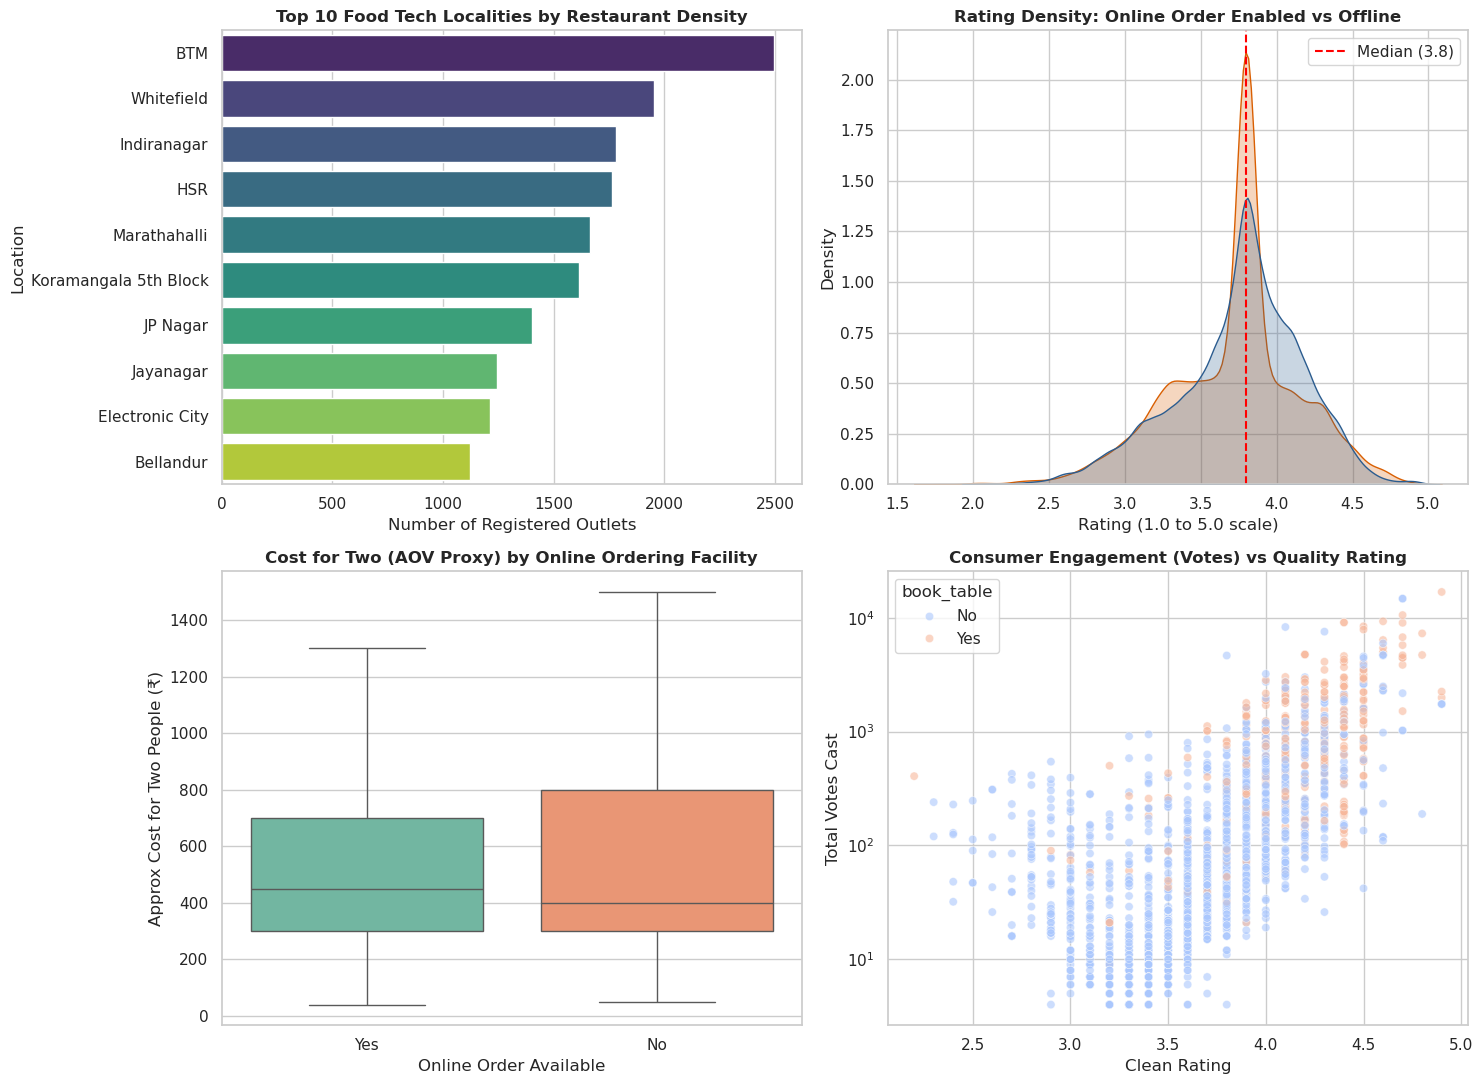

Dashboard exported as 'zomato_product_eda_visualizations.png'.


In [17]:
# ------------------------------------------------------------------------------
# 4. PUBLICATION-GRADE VISUAL DASHBOARD (4-Panel Visual Analytics)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 4.1 Top 10 High-Density Restaurant Localities
sns.barplot(data=top_locations, x="Restaurant_Count", y="Location", hue="Location", legend=False, ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Top 10 Food Tech Localities by Restaurant Density", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Number of Registered Outlets")

# 4.2 Rating Distribution (Online Order vs Dine-In)
sns.kdeplot(data=df, x="rating_clean", hue="online_order", common_norm=False, fill=True, ax=axes[0, 1], palette=["#2b5c8f", "#d95f02"])
axes[0, 1].axvline(median_rating, color="red", linestyle="--", label=f"Median ({median_rating})")
axes[0, 1].set_title("Rating Density: Online Order Enabled vs Offline", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Rating (1.0 to 5.0 scale)")
axes[0, 1].legend()

# 4.3 Cost for Two Distribution vs Online Delivery (Boxplot)
sns.boxplot(data=df, x="online_order", y="cost_for_two_clean", hue="online_order", legend=False, ax=axes[1, 0], palette="Set2", showfliers=False)
axes[1, 0].set_title("Cost for Two (AOV Proxy) by Online Ordering Facility", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Online Order Available")
axes[1, 0].set_ylabel("Approx Cost for Two People (₹)")

# 4.4 Voting Engagement vs Rating Scatter Plot
sample_df = df.sample(n=2500, random_state=42)
sns.scatterplot(data=sample_df, x="rating_clean", y="votes", hue="book_table", alpha=0.6, ax=axes[1, 1], palette="coolwarm")
axes[1, 1].set_title("Consumer Engagement (Votes) vs Quality Rating", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Clean Rating")
axes[1, 1].set_ylabel("Total Votes Cast")
axes[1, 1].set_yscale("log")

plt.tight_layout()
plt.savefig("zomato_product_eda_visualizations.png", dpi=300)
plt.show()
print("Dashboard exported as 'zomato_product_eda_visualizations.png'.")